<!--nav-->
> **Обучающая цепочка · 2/8.**  ·  ← [предыдущий](01_circle_api.ipynb)  ·  [следующий](03_compose_cutout.ipynb) →  
> *Чему учит:* постановка case-файлом, верификация `plate-verify`, свип сходимости; многосвязная область (кольцо).

# 02 — Кольцо case-файлом: решение, верификация, свип

Case: `cases/ci/annulus_soft.toml` (лёгкая копия ladder-ступени).

In [1]:
from plate_solver.dispatch import solve
from plate_solver.problem import Problem
from plate_solver.references import verify_result

problem = Problem.from_toml("../cases/ci/annulus_soft.toml")
res = solve(problem)
report = verify_result(res)
print(report.table())
print("вердикт:", "PASS" if report.ok else "FAIL")

| эталон | w_max эталона | w_max расчёта | rel | статус |
|---|---|---|---|---|
| analytic (annulus, soft_hinge) | 1.699305e-04 | 1.687553e-04 | 6.92e-03 | PASS |
| 1D-Ритц по радиусу (annulus, soft_hinge) | 1.699305e-04 | 1.687553e-04 | 6.92e-03 | PASS |
| истинный Кирхгоф (model_gap, вне допуска) | 1.547234e-04 | 1.687553e-04 | 9.07e-02 | инфо |
вердикт: PASS


Свип сходимости по p — то же, что `plate-verify … --sweep p=2:10:2`.

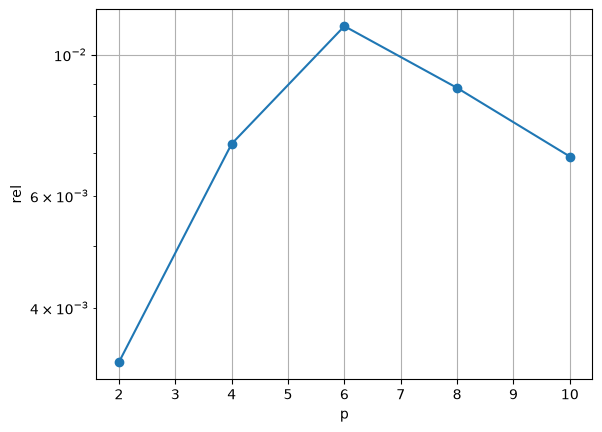

In [2]:
import dataclasses

import matplotlib.pyplot as plt

ps, rels = [], []
for p in (2, 4, 6, 8, 10):
    prob = dataclasses.replace(problem, discretization=dataclasses.replace(
        problem.discretization, p=p))
    rep = verify_result(solve(prob))
    ps.append(p)
    rels.append(max(r.rel for r in rep.rows if r.gated))
plt.semilogy(ps, rels, "o-")
plt.xlabel("p")
plt.ylabel("rel")
plt.grid(True)

## Вращаемая 3D-поверхность (ipympl)

Требует extra: `pip install -e ".[notebooks]"`. Без ipympl закомментируйте магию — останется статический ракурс.

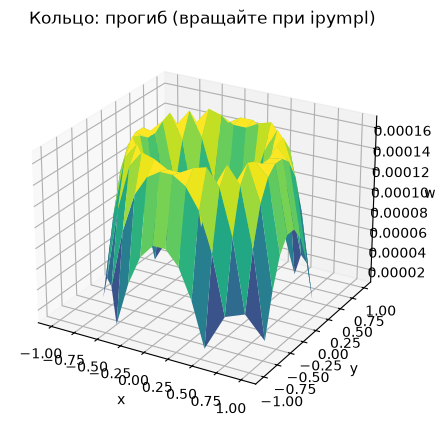

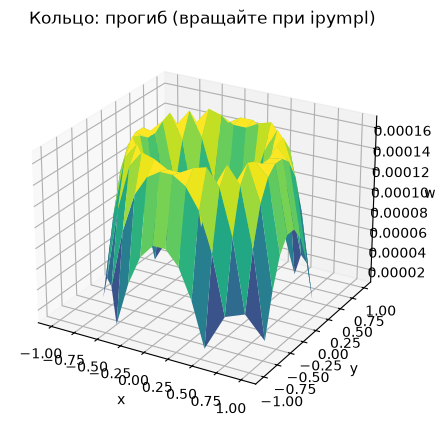

In [3]:
# %matplotlib widget   # ← раскомментируйте при установленном ipympl (вращение мышью)
from plate_solver import viz

res2 = solve(problem)
viz.surface3d(res2.Xg, res2.Yg, res2.w_grid, elev=25, azim=-60,
              title="Кольцо: прогиб (вращайте при ipympl)")

Рабочий сценарий сетки вывода: решаем на компактной сетке кейса, смотрим, затем `result.regrid(128)` — мгновенное уплотнение картинки БЕЗ пересчёта (числа решения от сетки не зависят; гладкое отверстие кольца).

сетка: (16, 16) -> (128, 128) | w_max неизменен: True


Text(0.5, 1.0, 'Кольцо: прогиб на уплотнённой сетке 128×128 (regrid)')

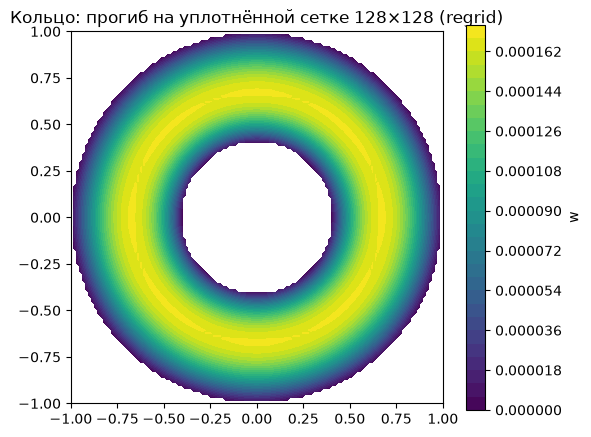

In [4]:
import numpy as np

fine = res.regrid(128)                       # только вывод, без пересчёта
print("сетка:", res.w_grid.shape, "->", fine.w_grid.shape,
      "| w_max неизменен:", fine.w_max == res.w_max)
fig, ax = plt.subplots(figsize=(6, 5))
pcm = ax.contourf(fine.Xg, fine.Yg, np.ma.masked_invalid(fine.w_grid),
                  levels=30, cmap="viridis")
fig.colorbar(pcm, ax=ax, label="w")
ax.set_aspect("equal")
ax.set_title("Кольцо: прогиб на уплотнённой сетке 128×128 (regrid)")
